In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load in 

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

import os
print(os.listdir("../input"))

from glob import glob 
from skimage.io import imread
import gc

from sklearn.model_selection import train_test_split
from keras.utils import to_categorical


['description.md', 'test', 'train', 'histopathologic-cancer-detection', 'test.zip', 'train.zip', 'train_labels.csv', 'sample_submission.csv.zip', 'train_labels.csv.zip', 'sample_submission.csv']


2026-01-06 23:39:34.471880: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1767742774.482254      11 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1767742774.486403      11 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-01-06 23:39:34.503844: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

In [2]:
base_tile_dir = '../input/train/'
df = pd.DataFrame({'path': glob(os.path.join(base_tile_dir,'*.tif'))})
df['id'] = df.path.map(lambda x: x.split('/')[3].split(".")[0])
labels = pd.read_csv("../input/train_labels.csv")
df = df.merge(labels, on = "id")
df.head(3)


,path,id,label
0,../input/train/bc9b47c5fd125f59519a4f719bf459f...,bc9b47c5fd125f59519a4f719bf459f919164104,0
1,../input/train/0874a429121cea137156954353d1b28...,0874a429121cea137156954353d1b287022a6f65,0
2,../input/train/0ca7627eaf902b8f6e4bb5d171a2dd4...,0ca7627eaf902b8f6e4bb5d171a2dd485abd0d88,0


In [3]:
SAMPLES_N = 10000
SAMPLES_P = 10000

df0 = df[df.label == 0].sample(SAMPLES_N, random_state = 42)
df1 = df[df.label == 1].sample(SAMPLES_P, random_state = 42)
df = pd.concat([df0, df1], ignore_index=True).reset_index()
df = df[["path", "id", "label"]]
df['image'] = df['path'].map(imread)

y = df["label"]
X = np.stack(df["image"].values)

y = to_categorical(y)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=42)

X_train = (X_train - X_train.mean()) / X_train.std()
X_test = (X_test - X_test.mean()) / X_test.std()


In [4]:
from keras.models import Sequential
from keras.layers import Dense, Dropout, Flatten
from keras.layers import Conv2D, MaxPool2D
from keras.optimizers import RMSprop, Adam

kernel_size = (3,3)
pool_size= (2,2)
first_filters = 32
second_filters = 64
third_filters = 128

dropout_conv = 0.3
dropout_dense = 0.3

model = Sequential()
model.add(Conv2D(first_filters, kernel_size, activation = 'relu', input_shape = (96, 96, 3)))
model.add(Conv2D(first_filters, kernel_size, activation = 'relu'))
model.add(Conv2D(first_filters, kernel_size, activation = 'relu'))
model.add(MaxPool2D(pool_size = pool_size)) 
model.add(Dropout(dropout_conv))

model.add(Conv2D(second_filters, kernel_size, activation ='relu'))
model.add(Conv2D(second_filters, kernel_size, activation ='relu'))
model.add(Conv2D(second_filters, kernel_size, activation ='relu'))
model.add(MaxPool2D(pool_size = pool_size))
model.add(Dropout(dropout_conv))

model.add(Conv2D(third_filters, kernel_size, activation ='relu'))
model.add(Conv2D(third_filters, kernel_size, activation ='relu'))
model.add(Conv2D(third_filters, kernel_size, activation ='relu'))
model.add(MaxPool2D(pool_size = pool_size))
model.add(Dropout(dropout_conv))

model.add(Flatten())
model.add(Dense(256, activation = "relu"))
model.add(Dropout(dropout_dense))
model.add(Dense(2, activation = "softmax"))

# Define the optimizer
optimizer = Adam(lr=0.001, beta_1=0.9, beta_2=0.999, epsilon=None, decay=0.0, amsgrad=False)

# Compile the model
model.compile(optimizer = optimizer , loss = "categorical_crossentropy", metrics=["accuracy"])


/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
2026-01-06 23:39:57.437327: W tensorflow/core/common_runtime/gpu/gpu_bfc_allocator.cc:47] Overriding orig_value setting because the TF_FORCE_GPU_ALLOW_GROWTH environment variable is set. Original config value was 0.
I0000 00:00:1767742797.437740      11 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 40095 MB memory:  -> device: 0, name: NVIDIA RTX A6000, pci bus id: 0000:46:00.0, compute capability: 8.6
/usr/local/lib/python3.11/dist-packages/keras/src/optimizers/base_optimizer.py:86: UserWarning: Argument `decay` is no longer supported and will be ignored.
  warnings.warn(


ValueError: Argument(s) not recognized: {'lr': 0.001}

In [5]:
from keras.callbacks import EarlyStopping

earlystopper = EarlyStopping(monitor='val_loss', patience=2, verbose=1, restore_best_weights=True)
history = model.fit(X_train, y_train, validation_data = (X_test, y_test), epochs=5, batch_size=64, callbacks=[earlystopper])


ValueError: You must call `compile()` before using the model.

I0000 00:00:1767742799.726646      65 service.cc:148] XLA service 0x7f3640003880 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1767742799.726685      65 service.cc:156]   StreamExecutor device (0): NVIDIA RTX A6000, Compute Capability 8.6
2026-01-06 23:39:59.734224: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:268] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1767742799.771257      65 cuda_dnn.cc:529] Loaded cuDNN version 90300


 61/207 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step

I0000 00:00:1767742800.914446      65 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


207/207 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step


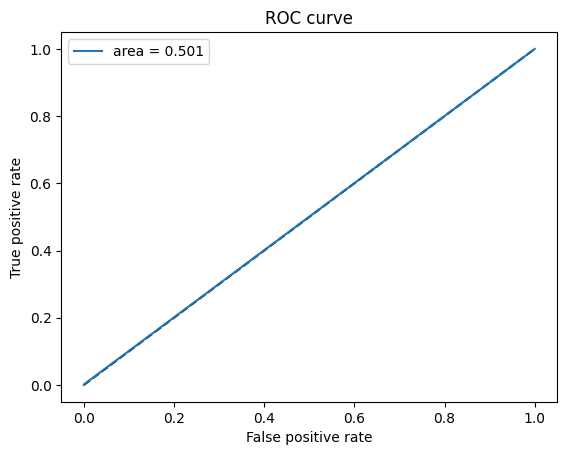

In [6]:
from sklearn.metrics import roc_curve, auc, roc_auc_score
import matplotlib.pyplot as plt

y_pred_keras = model.predict(X_test)
fpr_keras, tpr_keras, thresholds_keras = roc_curve(y_test.argmax(axis=1), y_pred_keras.argmax(axis=1))
auc_keras = auc(fpr_keras, tpr_keras)

plt.figure(1)
plt.plot([0, 1], [0, 1], 'k--')
plt.plot(fpr_keras, tpr_keras, label='area = {:.3f}'.format(auc_keras))
plt.xlabel('False positive rate')
plt.ylabel('True positive rate')
plt.title('ROC curve')
plt.legend(loc='best')
plt.show()


In [7]:
base_test_dir = '../input/test/'
test_files = glob(os.path.join(base_test_dir,'*.tif'))
submission = pd.DataFrame()
file_batch = 5000
max_idx = len(test_files)
for idx in range(0, max_idx, file_batch):
    print("Indexes: %i - %i"%(idx, idx+file_batch))
    test_df = pd.DataFrame({'path': test_files[idx:idx+file_batch]})
    test_df['id'] = test_df.path.map(lambda x: x.split('/')[3].split(".")[0])
    test_df['image'] = test_df['path'].map(imread)
    K_test = np.stack(test_df["image"].values)
    K_test = (K_test - K_test.mean()) / K_test.std()
    predictions = model.predict(K_test)
    test_df['label'] = predictions.argmax(axis=1)
    submission = pd.concat([submission, test_df[["id", "label"]]])
submission.head()


Indexes: 0 - 5000
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
Indexes: 5000 - 10000
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Indexes: 10000 - 15000
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Indexes: 15000 - 20000
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
Indexes: 20000 - 25000
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
Indexes: 25000 - 30000
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
Indexes: 30000 - 35000
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Indexes: 35000 - 40000
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Indexes: 40000 - 45000
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Indexes: 45000 - 50000
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 54ms/step


,id,label
0,7d1637c3535cd849727c50dff5fb0efd42f500a7,0
1,c66203935db093d22a62c667636345dab7ee67ba,0
2,f79498aab7f5e43109efb24b3bcc850101102f66,0
3,697cccea61869921cd992e7bbb111fe26475685a,0
4,c92685d04e3d905d2db02d608dff7e8226e41a1c,0


In [8]:
#submission
submission.to_csv("submission.csv", index = False, header = True)
